# Imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import contractions
import re
import string

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, FunctionTransformer
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split, cross_validate, KFold
from sklearn.multiclass import OneVsRestClassifier
from scipy.sparse import hstack, csr_matrix

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score, make_scorer, hamming_loss, ConfusionMatrixDisplay

In [2]:
# option to show all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 5000)

# Import Data

In [3]:
df = pd.read_csv('train.csv')

# Preprocessing

In [4]:
df['processed_text'] = df['comment_text'].apply(lambda x: re.sub(r'\n', ' ', str(x)))
df['processed_text'] = df['processed_text'].apply(lambda x: re.sub(r'[^a-zA-Z0-9\s.,!?;:()-]', '', str(x)))
df['processed_text'] = df['processed_text'].str.lower()
df['processed_text'] = df['processed_text'].apply(lambda x: contractions.fix(str(x)))
df['processed_text'] = df['processed_text'].apply(lambda x: x.translate(str.maketrans('', '', string.punctuation)))
df['tokens'] = df['processed_text'].apply(lambda x: nltk.word_tokenize(str(x)))
STOPWORDS = set(stopwords.words('english'))
df['tokens'] = df['tokens'].apply(lambda x: [word for word in x if word not in STOPWORDS])
lemmatizer = WordNetLemmatizer()
df['tokens'] = df['tokens'].apply(lambda x: [lemmatizer.lemmatize(word) for word in x])
df['processed_text'] = df['tokens'].apply(lambda x: re.sub(r'\s+', ' ', " ".join(x)).strip())

df['word_count'] = df['comment_text'].apply(lambda x: len(x.split())) 
df['unique_word_count'] = df['comment_text'].apply(lambda x: len(set(x.split())))
df['char_count'] = df['comment_text'].apply(lambda x: len(x))
df['upper_chars'] = df['comment_text'].apply(lambda x: sum([1 if char.isupper() else 0 for char in x]))
df['upper_words'] = df['comment_text'].apply(lambda x: sum([1 if word.isupper() else 0 for word in x.split()]))
df['punctuation_count'] = df['comment_text'].apply(lambda x: sum([1 if char in string.punctuation else 0 for char in x]))
df['biggest_word'] = df['comment_text'].apply(lambda x: len(max(x.split(), key=len)))
df['perc_punctuation'] = df['punctuation_count'] / (df['punctuation_count'] + df['char_count'])
df['perc_upper_chars'] = df['upper_chars'] / df['char_count']
df['perc_upper_words'] = df['upper_words'] / df['word_count']
df['avg_word_size'] = df['char_count'] / df['word_count']

In [5]:
df

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,processed_text,tokens,word_count,unique_word_count,char_count,upper_chars,upper_words,punctuation_count,biggest_word,perc_punctuation,perc_upper_chars,perc_upper_words,avg_word_size
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,explanation edits made username hardcore metal...,"[explanation, edits, made, username, hardcore,...",43,41,264,17,2,10,16,0.036496,0.064394,0.046512,6.139535
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,daww match background colour seemingly stuck t...,"[daww, match, background, colour, seemingly, s...",17,17,112,8,1,12,10,0.096774,0.071429,0.058824,6.588235
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,hey man really trying edit war guy constantly ...,"[hey, man, really, trying, edit, war, guy, con...",42,39,233,4,0,6,11,0.025105,0.017167,0.000000,5.547619
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,make real suggestion improvement wondered sect...,"[make, real, suggestion, improvement, wondered...",113,82,622,11,5,21,44,0.032659,0.017685,0.044248,5.504425
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,sir hero chance remember page,"[sir, hero, chance, remember, page]",13,13,67,2,0,5,8,0.069444,0.029851,0.000000,5.153846
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,0,0,0,0,0,second time asking view completely contradicts...,"[second, time, asking, view, completely, contr...",47,44,295,2,0,18,13,0.057508,0.006780,0.000000,6.276596
159567,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0,ashamed horrible thing put talk page 128611993,"[ashamed, horrible, thing, put, talk, page, 12...",18,18,99,2,0,4,12,0.038835,0.020202,0.000000,5.500000
159568,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0,spitzer umm actual article prostitution ring c...,"[spitzer, umm, actual, article, prostitution, ...",12,12,81,4,0,4,12,0.047059,0.049383,0.000000,6.750000
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,0,0,0,0,0,look like actually put speedy first version de...,"[look, like, actually, put, speedy, first, ver...",25,23,116,2,1,1,8,0.008547,0.017241,0.040000,4.640000


# Train Test Split

In [6]:
input_string = ['comment_text']

numerical_features = ['word_count', 'unique_word_count', 'char_count', 'upper_chars', 'upper_words', 'punctuation_count', 'biggest_word', 
            'perc_punctuation', 'perc_upper_chars', 'perc_upper_words', 'avg_word_size']

targets = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

In [7]:
# we need to add the processed_text to perform the bag of words and then we drop it
X = df[numerical_features + ['processed_text']]
y = df[targets]

comment_text_all = df[input_string]

In [8]:
X_train, X_test, y_train, y_test, text_train, text_test = train_test_split(X, y, comment_text_all, test_size=0.2, random_state=10)

# TF-IDF

In [9]:
# # using raw counts (bag of words) - Train - dense matrix
# vectorizer = CountVectorizer(max_features = 500, min_df = 5, max_df=0.9, ngram_range=(1,2))

# train_bag_of_words = vectorizer.fit_transform(X_train['processed_text'])
# train_bag_of_words_dense = train_bag_of_words.toarray()

# feature_names = vectorizer.get_feature_names_out()
# train_bag_of_words_df = pd.DataFrame(train_bag_of_words_dense, columns=feature_names, index=X_train.index)

# X_train = pd.concat([X_train.drop('processed_text', axis = 1), train_bag_of_words_df], axis=1)

In [10]:
# using raw counts (bag of words) - Train - sparse matrix
vectorizer = TfidfVectorizer(max_features = 2500, min_df = 5, max_df=0.9, ngram_range=(1,2))

train_tf_idf_sparse = vectorizer.fit_transform(X_train['processed_text'])

feature_names = vectorizer.get_feature_names_out()

X_train_numerical_features_df = X_train.drop('processed_text', axis=1)
X_train_numerical_sparse = csr_matrix(X_train_numerical_features_df.values)
numerical_feature_names = X_train_numerical_features_df.columns.tolist()

X_train = hstack([X_train_numerical_sparse, train_tf_idf_sparse])

In [11]:
# # using raw counts (bag of words) - Test - dense matrix
# test_bag_of_words = vectorizer.transform(X_test['processed_text'])
# test_bag_of_words_dense = test_bag_of_words.toarray()

# feature_names = vectorizer.get_feature_names_out()
# test_bag_of_words_df = pd.DataFrame(test_bag_of_words_dense, columns=feature_names, index=X_test.index)

# X_test = pd.concat([X_test.drop('processed_text', axis = 1), test_bag_of_words_df], axis=1)

In [12]:
# using raw counts (bag of words) - Test - sparse matrix
test_tf_idf_sparse = vectorizer.transform(X_test['processed_text'])

X_test_numerical_features_df = X_test.drop('processed_text', axis=1)
X_test_numerical_sparse = csr_matrix(X_test_numerical_features_df.values)
numerical_feature_names = X_test_numerical_features_df.columns.tolist()

X_test = hstack([X_test_numerical_sparse, test_tf_idf_sparse])

# Logistic Regression

In [24]:
base_classifier = LogisticRegression(random_state=42, solver='liblinear')
multi_label_model = OneVsRestClassifier(base_classifier, n_jobs=-1)

param_grid = {

}

f1_micro_scorer = make_scorer(f1_score, average='micro')

grid_search = GridSearchCV(
    estimator=multi_label_model,
    param_grid=param_grid,
    scoring=f1_micro_scorer, # Use your multi-label F1-score for optimization
    cv=5,
    verbose=100,             # Higher verbosity shows more progress
    n_jobs=1,             # Parallelize grid search folds
    return_train_score=True # Useful for checking for overfitting
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV 1/5; 1/1] START ............................................................
[CV 1/5; 1/1] END .........., score=(train=0.130, test=0.130) total time=  11.4s
[CV 2/5; 1/1] START ............................................................
[CV 2/5; 1/1] END .........., score=(train=0.080, test=0.081) total time=  12.2s
[CV 3/5; 1/1] START ............................................................
[CV 3/5; 1/1] END .........., score=(train=0.067, test=0.068) total time=  10.8s
[CV 4/5; 1/1] START ............................................................
[CV 4/5; 1/1] END .........., score=(train=0.199, test=0.203) total time=  11.8s
[CV 5/5; 1/1] START ............................................................
[CV 5/5; 1/1] END .........., score=(train=0.166, test=0.158) total time=  11.4s


GridSearchCV(cv=5,
             estimator=OneVsRestClassifier(estimator=LogisticRegression(random_state=42,
                                                                        solver='liblinear'),
                                           n_jobs=-1),
             n_jobs=1, param_grid={}, return_train_score=True,
             scoring=make_scorer(f1_score, response_method='predict', average=micro),
             verbose=100)

In [14]:
print("\n--- Grid Search Results ---")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation score (Micro F1): {grid_search.best_score_:.4f}")


--- Grid Search Results ---
Best parameters found: {}
Best cross-validation score (Micro F1): 0.1278


In [15]:
best_multi_label_model = grid_search.best_estimator_

In [16]:
y_pred_best = best_multi_label_model.predict(X_test)

print(f"Hamming Loss on test set: {hamming_loss(y_test, y_pred_best):.4f}")
print(f"Micro F1 on test set: {f1_score(y_test, y_pred_best, average='micro'):.4f}")

Hamming Loss on test set: 0.0355
Micro F1 on test set: 0.0598


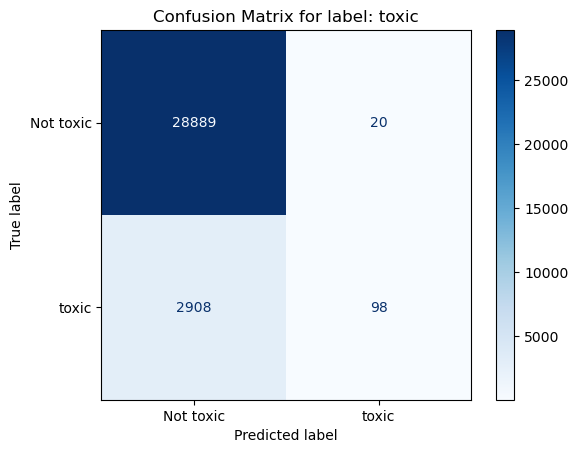

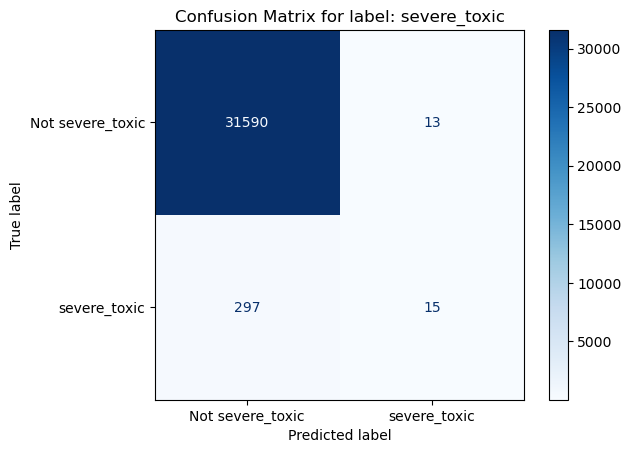

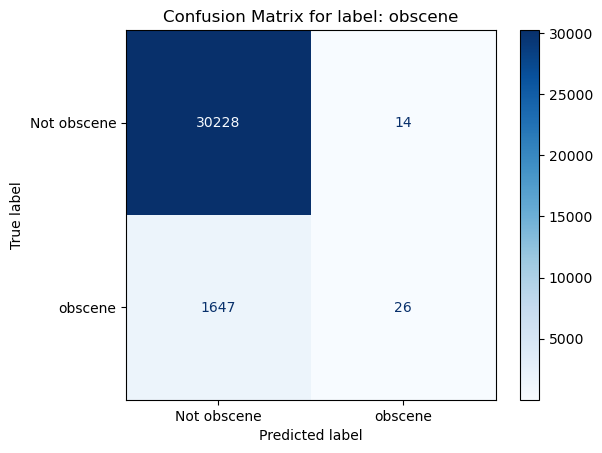

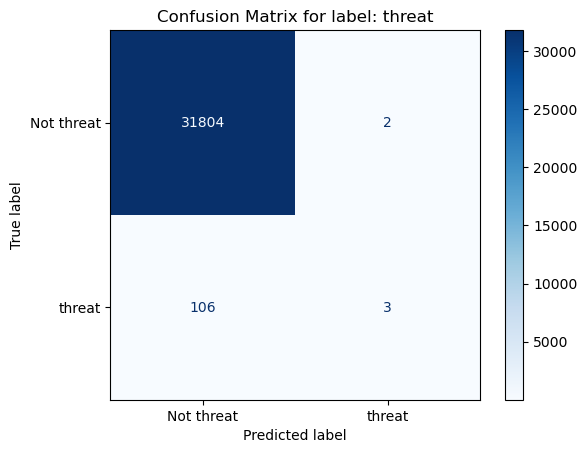

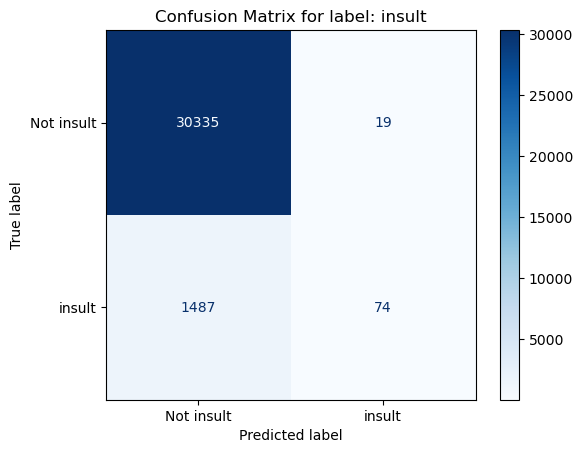

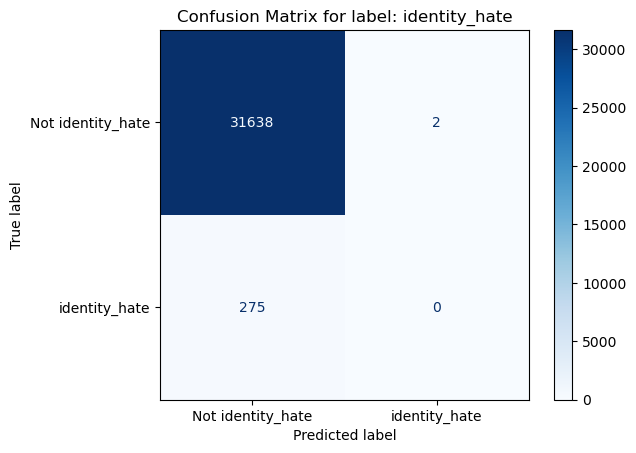

In [17]:
# Loop over each target (label) in the multi-label setting
for i, label in enumerate(targets):
    # Extract ground truth and predictions for this specific label
    y_true_label = y_test.iloc[:, i]
    y_pred_label = y_pred_best[:, i]

    # Compute the confusion matrix
    cm = confusion_matrix(y_true_label, y_pred_label)

    # Display the confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f'Not {label}', label])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'Confusion Matrix for label: {label}')
    plt.show()

# Random Forest

In [36]:
base_classifier = RandomForestClassifier(random_state=42)
multi_label_model = OneVsRestClassifier(base_classifier, n_jobs=-1)

# param_grid = {
#     'estimator__n_estimators': [200, 500],           # Number of trees
#     'estimator__max_depth': [50, 100, 200],        # Max depth of the tree
#     'estimator__min_samples_split': [2, 5],              # Min samples to split an internal node
#     'estimator__min_samples_leaf': [1, 2],               # Min samples at a leaf node
# }

# empty grid just to create a simple training test to check the time required to fit the model
param_grid = {
        'estimator__n_estimators': [200, 500],           # Number of trees
        'estimator__max_depth': [50, 100, 200],        # Max depth of the tree
}

f1_micro_scorer = make_scorer(f1_score, average='micro')

grid_search = GridSearchCV(
    estimator=multi_label_model,
    param_grid=param_grid,
    scoring=f1_micro_scorer, # Use your multi-label F1-score for optimization
    cv=5,
    verbose=100,             # Higher verbosity shows more progress
    n_jobs=4,             # Parallelize grid search folds
    return_train_score=True # Useful for checking for overfitting
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


GridSearchCV(cv=5,
             estimator=OneVsRestClassifier(estimator=RandomForestClassifier(random_state=42),
                                           n_jobs=-1),
             n_jobs=4, param_grid={}, return_train_score=True,
             scoring=make_scorer(f1_score, response_method='predict', average=micro),
             verbose=100)

In [37]:
print("\n--- Grid Search Results ---")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation score (Micro F1): {grid_search.best_score_:.4f}")


--- Grid Search Results ---
Best parameters found: {}
Best cross-validation score (Micro F1): 0.6642


In [38]:
best_multi_label_model = grid_search.best_estimator_

In [39]:
y_pred_best = best_multi_label_model.predict(X_test)

print(f"Hamming Loss on test set: {hamming_loss(y_test, y_pred_best):.4f}")
print(f"Micro F1 on test set: {f1_score(y_test, y_pred_best, average='micro'):.4f}")

Hamming Loss on test set: 0.0199
Micro F1 on test set: 0.6719


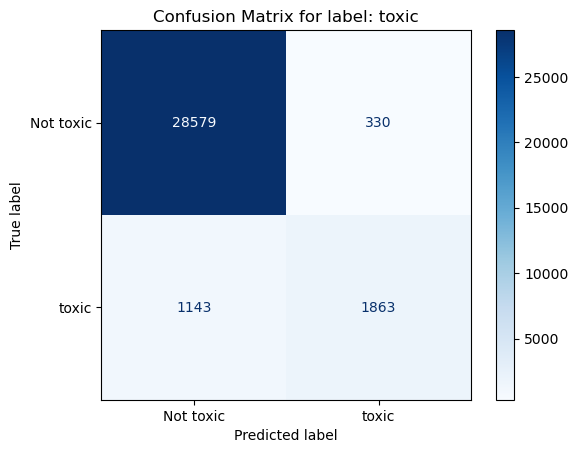

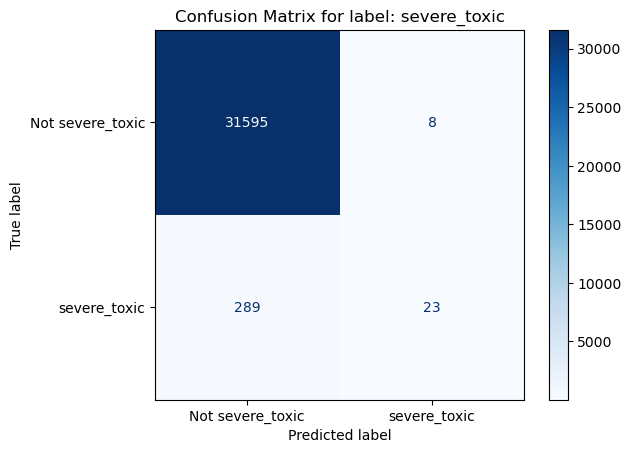

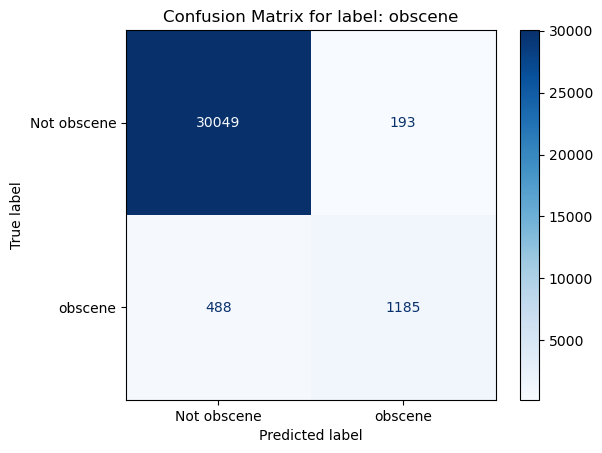

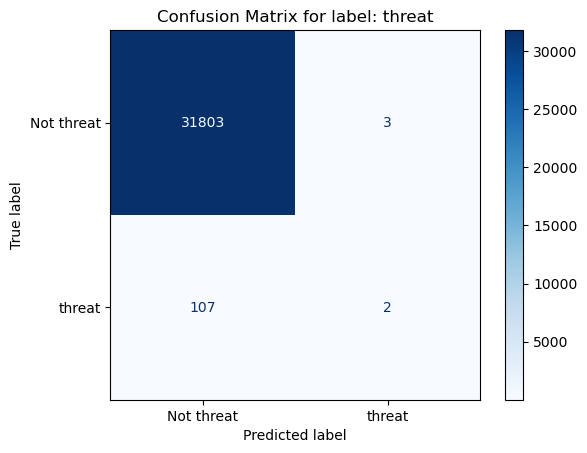

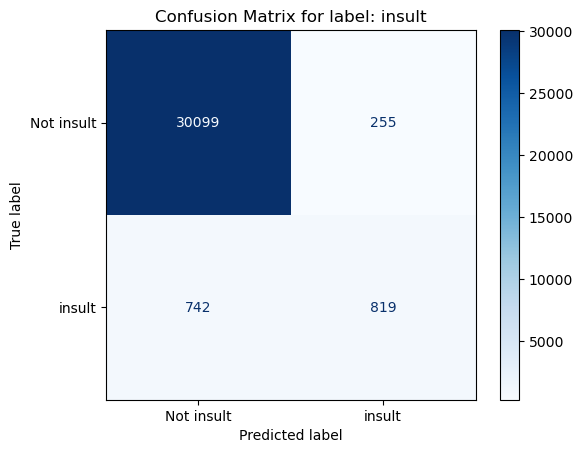

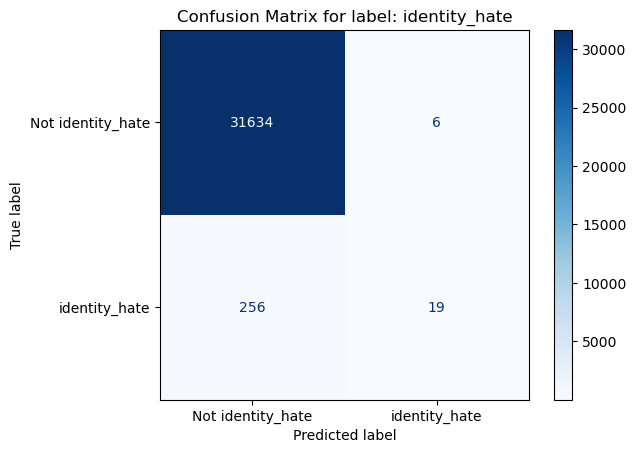

In [40]:
# Loop over each target (label) in the multi-label setting
for i, label in enumerate(targets):
    # Extract ground truth and predictions for this specific label
    y_true_label = y_test.iloc[:, i]
    y_pred_label = y_pred_best[:, i]

    # Compute the confusion matrix
    cm = confusion_matrix(y_true_label, y_pred_label)

    # Display the confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f'Not {label}', label])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'Confusion Matrix for label: {label}')
    plt.show()

In [41]:
all_feature_names = numerical_feature_names + list(vectorizer.get_feature_names_out())

estimators = best_multi_label_model.estimators_

for i, (label, estimator) in enumerate(zip(targets, estimators)):
    importances = estimator.feature_importances_
    importance_df = pd.DataFrame({
        'Feature': all_feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    print(f"\nTop Features for Label: {label}")
    print(importance_df.head(10))  # Top 10 features


Top Features for Label: toxic
               Feature  Importance
949               fuck    0.067998
956            fucking    0.041178
8     perc_upper_chars    0.026372
2012              shit    0.025892
9     perc_upper_words    0.022536
2152              suck    0.021050
2142            stupid    0.018478
1104             idiot    0.018215
217                 as    0.017931
2           char_count    0.016028

Top Features for Label: severe_toxic
               Feature  Importance
949               fuck    0.064867
8     perc_upper_chars    0.034837
10       avg_word_size    0.033264
2           char_count    0.032803
956            fucking    0.031883
3          upper_chars    0.029968
0           word_count    0.029047
7     perc_punctuation    0.027669
1    unique_word_count    0.025331
6         biggest_word    0.023717

Top Features for Label: obscene
               Feature  Importance
949               fuck    0.128032
956            fucking    0.069824
2012              shit 

# XGBoost

In [17]:
base_classifier = XGBClassifier(objective='binary:logistic', eval_metric='mlogloss', random_state=42)
multi_label_model = OneVsRestClassifier(base_classifier, n_jobs=-1)

param_grid = {
    'estimator__n_estimators': [100],
    'estimator__max_depth': [10],
    #'estimator__learning_rate': [0.01, 0.1, 0.2],
}

# empty grid just to create a simple training test to check the time required to fit the model
# param_grid = {
# }

f1_micro_scorer = make_scorer(f1_score, average='micro')

grid_search = GridSearchCV(
    estimator=multi_label_model,
    param_grid=param_grid,
    scoring=f1_micro_scorer, # Use your multi-label F1-score for optimization
    cv=5,
    verbose=100,             # Higher verbosity shows more progress
    n_jobs=1,             # Parallelize grid search folds
    return_train_score=True # Useful for checking for overfitting
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV 1/5; 1/1] START estimator__max_depth=10, estimator__n_estimators=100........
[CV 1/5; 1/1] END estimator__max_depth=10, estimator__n_estimators=100;, score=(train=0.861, test=0.685) total time= 1.5min
[CV 2/5; 1/1] START estimator__max_depth=10, estimator__n_estimators=100........
[CV 2/5; 1/1] END estimator__max_depth=10, estimator__n_estimators=100;, score=(train=0.865, test=0.683) total time= 1.5min
[CV 3/5; 1/1] START estimator__max_depth=10, estimator__n_estimators=100........
[CV 3/5; 1/1] END estimator__max_depth=10, estimator__n_estimators=100;, score=(train=0.865, test=0.677) total time= 1.4min
[CV 4/5; 1/1] START estimator__max_depth=10, estimator__n_estimators=100........
[CV 4/5; 1/1] END estimator__max_depth=10, estimator__n_estimators=100;, score=(train=0.863, test=0.675) total time= 1.4min
[CV 5/5; 1/1] START estimator__max_depth=10, estimator__n_estimators=100........
[CV 5/5; 1/1] END estimator__max_depth=1

GridSearchCV(cv=5,
             estimator=OneVsRestClassifier(estimator=XGBClassifier(base_score=None,
                                                                   booster=None,
                                                                   callbacks=None,
                                                                   colsample_bylevel=None,
                                                                   colsample_bynode=None,
                                                                   colsample_bytree=None,
                                                                   device=None,
                                                                   early_stopping_rounds=None,
                                                                   enable_categorical=False,
                                                                   eval_metric='mlogloss',
                                                                   feature_types=None,
                                                                   feature_weights=None,
                                                                   gamma=None,
                                                                   grow_policy=None,
                                                                   importance_t...
                                                                   max_leaves=None,
                                                                   min_child_weight=None,
                                                                   missing=nan,
                                                                   monotone_constraints=None,
                                                                   multi_strategy=None,
                                                                   n_estimators=None,
                                                                   n_jobs=None,
                                                                   num_parallel_tree=None, ...),
                                           n_jobs=-1),
             n_jobs=1,
             param_grid={'estimator__max_depth': [10],
                         'estimator__n_estimators': [100]},
             return_train_score=True,
             scoring=make_scorer(f1_score, response_method='predict', average=micro),
             verbose=100)

In [18]:
print("\n--- Grid Search Results ---")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation score (Micro F1): {grid_search.best_score_:.4f}")


--- Grid Search Results ---
Best parameters found: {'estimator__max_depth': 10, 'estimator__n_estimators': 100}
Best cross-validation score (Micro F1): 0.6811


In [19]:
best_multi_label_model = grid_search.best_estimator_

In [20]:
y_pred_best = best_multi_label_model.predict(X_test)

print(f"Hamming Loss on test set: {hamming_loss(y_test, y_pred_best):.4f}")
print(f"Micro F1 on test set: {f1_score(y_test, y_pred_best, average='micro'):.4f}")

Hamming Loss on test set: 0.0200
Micro F1 on test set: 0.6799


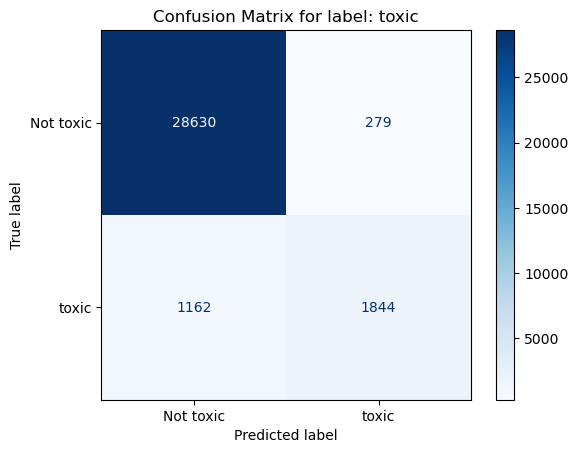

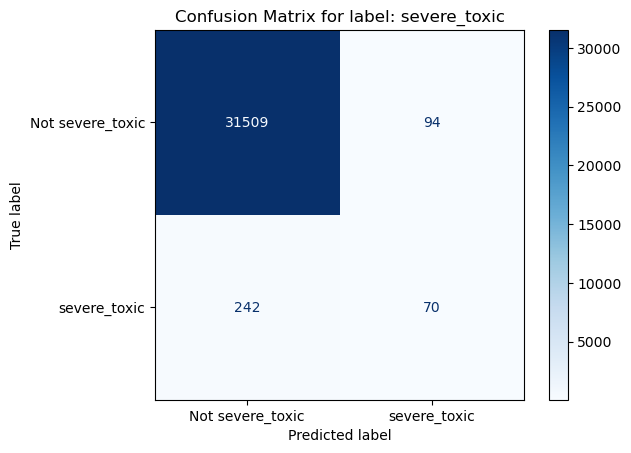

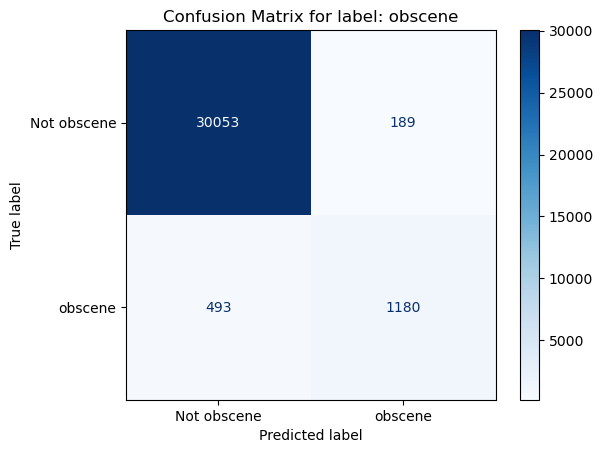

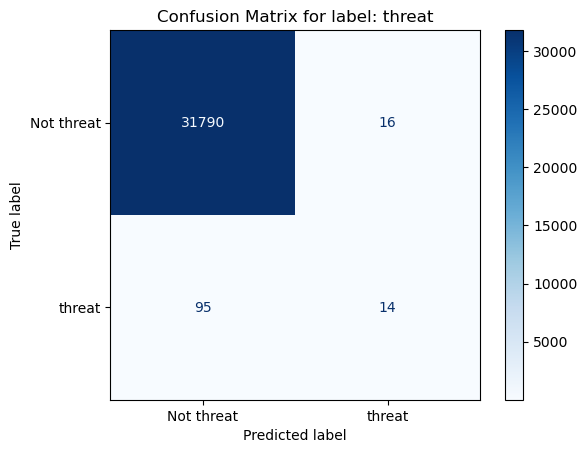

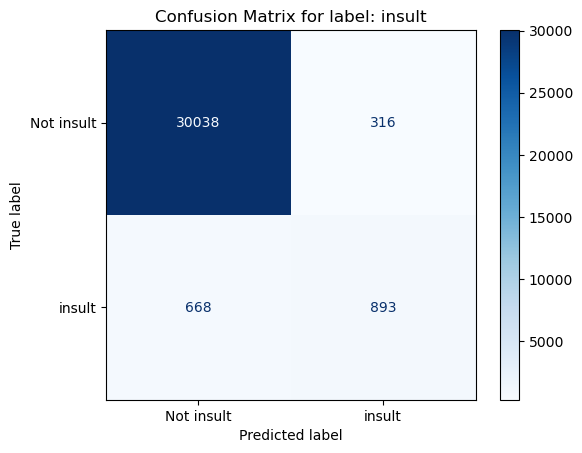

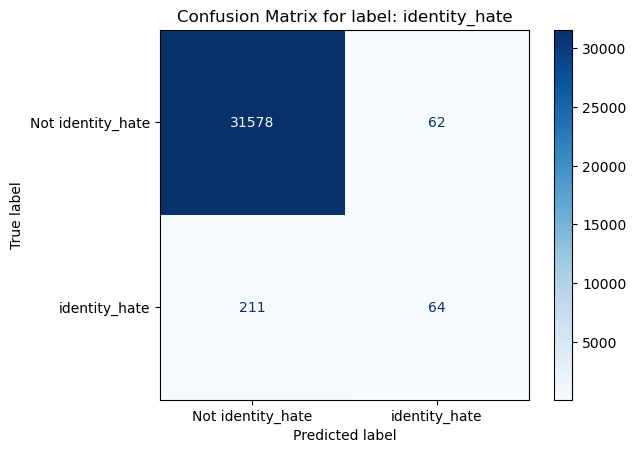

In [21]:
# Loop over each target (label) in the multi-label setting
for i, label in enumerate(targets):
    # Extract ground truth and predictions for this specific label
    y_true_label = y_test.iloc[:, i]
    y_pred_label = y_pred_best[:, i]

    # Compute the confusion matrix
    cm = confusion_matrix(y_true_label, y_pred_label)

    # Display the confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f'Not {label}', label])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'Confusion Matrix for label: {label}')
    plt.show()

In [22]:
all_feature_names = numerical_feature_names + list(vectorizer.get_feature_names_out())

estimators = best_multi_label_model.estimators_

for i, (label, estimator) in enumerate(zip(targets, estimators)):
    importances = estimator.feature_importances_
    importance_df = pd.DataFrame({
        'Feature': all_feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    print(f"\nTop Features for Label: {label}")
    print(importance_df.head(10))  # Top 10 features


Top Features for Label: toxic
      Feature  Importance
949      fuck    0.055383
956   fucking    0.035936
2012     shit    0.021340
316     bitch    0.020520
2152     suck    0.020502
230   asshole    0.019014
217        as    0.015011
1104    idiot    0.014875
2142   stupid    0.011886
842    faggot    0.010058

Top Features for Label: severe_toxic
               Feature  Importance
4          upper_words    0.440020
9     perc_upper_words    0.358192
949               fuck    0.043400
956            fucking    0.007973
2152              suck    0.006558
993            go fuck    0.006483
955             fuckin    0.004249
316              bitch    0.002773
842             faggot    0.002424
1044              head    0.002078

Top Features for Label: obscene
      Feature  Importance
949      fuck    0.099620
316     bitch    0.077057
956   fucking    0.063893
2152     suck    0.049814
842    faggot    0.031153
2012     shit    0.028617
587      cunt    0.027205
230   asshole    0.

# Notes

The results between tf-idf and bag of words were basically the same, except for logistic regression that showed worse results. And they keep increasing as I add more features until 2.5k. Due to memory issues I couldn't add more features or increase the complexity of model.

| Model    | Approach | Micro F1 | Hamming Loss |
| -------- | ------- | ------- | ------- |
| LogReg  | Baseline    | 0.0894 | 0.0354 |
| LogReg  | BagOfWords 500 features   | 0.3395 | 0.0303 |
| LogReg  | TD-IDF 500 features   | 0.1274 | 0.0343 |
| LogReg  | BagOfWords 1k features   | 0.4903 | 0.0264 |
| LogReg  | TD-IDF 1k features   | 0.0635 | 0.0354 |
| LogReg  | BagOfWords 2.5k features   | 0.2206 | 0.0323 |
| LogReg  | TD-IDF 2.5k features   | 0.0598 | 0.0355 |
| -------- | ------- | ------- | ------- |
| RandomForest  | Baseline    | 0.1547 | 0.0377 |
| RandomForest  | BagOfWords 500 features   | 0.5713 | 0.0238 |
| RandomForest  | TD-IDF 500 features   | 0.5824 | 0.0236 |
| RandomForest  | BagOfWords 1k features   | 0.6618 | 0.0205 |
| RandomForest  | TD-IDF 1k features   | 0.5713 | 0.0238 |
| RandomForest  | BagOfWords 2.5k features   | 0.6591 | 0.0203 |
| RandomForest  | TD-IDF 2.5k features   | 0.6719 | 0.0199 |
| -------- | ------- | ------- | ------- |
| XGBoost  | Baseline    | 0.1347 | 0.0361 |
| XGBoost  | BagOfWords 500 features   | 0.5906 | 0.0235 | 
| XGBoost  | TD-IDF 500 features   | 0.5889 | 0.0237 | 
| XGBoost  | BagOfWords 1k features   | 0.6686 | 0.0205 |
| XGBoost  | TD-IDF 1k features   | 0.6678 | 0.0205 | 
| XGBoost  | BagOfWords 2.5k features   | 0.6864 | 0.0198 |
| XGBoost  | TD-IDF 2.5k features   | 0.6799 | 0.0200 | 

If I had more computacional resources I would increase the number of features using bigger ngrams and also try more complex models (deeper and bigger trees). I would also try to use a languague checker to correct some typos that are typical in toxic messages like repeating characters or lack of proper spacing between words. I would also use a more complex lematizer that uses POS tagging. And to create a different set of features, instead of using BoW or TF-IDF I would use word embeddings such as a pre-trained W2V. With these embeddings I would create vectors for each comment that could then be fed into a classifier